---
authors:
    - Laura Köhler
title: BACSAM II quicklooks
label: template
---
# Quicklooks for BACSAM II with *Polar 6*

Author(s) of this notebook:
 - *Laura Köhler*, [*Alfred Wegener Institite*](*www.awi.de*), *Am Handelshafen 12, 27570 Bremerhaven, Germany*, *laura.koehler@awi.de*

This notebook is licensed under the [Creative Commons Attribution 4.0 International](http://creativecommons.org/licenses/by/4.0/ "CC-BY-4.0")

## Dataset description

**Title:** 100 Hz meteorological nose boom observations from the BACSAM II aircraft campaign with Polar 6 [dataset]     

**Authors:** Köhler, Laura; Hartmann, Jörg

**Data hosted by:** [PANGAEA](https://pangaea.de)

**Year:** 2026

**Institute(s):** Alfred-Wegener-Institut

**DOI:** https://doi.pangaea.de/10.1594/PANGAEA.995974

**License:**    [Creative Commons Attribution 4.0 International](http://creativecommons.org/licenses/by/4.0/)

## Contents of this notebook

*Quicklooks of turbulence data from polar aircrafts*

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import numpy as np
import pandas as pd
import yaml
from scipy.signal import csd, detrend
from mpl_toolkits.mplot3d import Axes3D

In [2]:
campaign_dir = "../Campaigns/20240403BACSAMII/Daten/"

## Quicklooks

### Noseboom

#### Definitions

In [3]:
def import_dictionary(yaml_file):
    try:
        with open(yaml_file, "r") as f:
            config = yaml.safe_load(f)
        return config
    except:
        print("yaml file not found or import error!!!")

In [4]:
def plot_wind_arrows(lat, lon, u, v, alt, flight,
                     track_stride=100,
                     wind_stride=1000,
                     wind_avg=500,
                     scale=0.003):

    lat_t = lat.isel(time=slice(None, None, track_stride)).values
    lon_t = lon.isel(time=slice(None, None, track_stride)).values
    alt_t = alt.isel(time=slice(None, None, track_stride)).values

    u_avg = u.rolling(time=wind_avg, center=True, min_periods=1).mean()
    v_avg = v.rolling(time=wind_avg, center=True, min_periods=1).mean()
    u_w = u_avg.isel(time=slice(None, None, wind_stride)).values
    v_w = v_avg.isel(time=slice(None, None, wind_stride)).values
    lat_w = lat.isel(time=slice(None, None, wind_stride)).values
    lon_w = lon.isel(time=slice(None, None, wind_stride)).values
    wspd = np.sqrt(u_w**2 + v_w**2)

    # --- Track as LineCollection (altitude color) ---
    points = np.array([lon_t, lat_t]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    norm_alt = mcolors.Normalize(vmin=np.nanmin(alt_t), vmax=np.nanmax(alt_t))
    cmap_alt = plt.cm.viridis

#    lc = LineCollection(segments, cmap=cmap_alt, norm=norm_alt,
#                        linewidth=1.2, alpha=0.8, zorder=1) # without cartopy

    # --- wind arrows ---
    norm_wind = mcolors.Normalize(vmin=np.nanmin(wspd), vmax=np.nanmax(wspd))
    cmap_wind = plt.cm.plasma

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

    # --- Map ---
#    ax.add_feature(cfeature.LAND,       facecolor="white")
#    ax.add_feature(cfeature.OCEAN,      facecolor="lightblue")
    ax.add_feature(cfeature.COASTLINE,  linewidth=0.5)

    # Zoomt automatisch auf den Track
    margin = 0.5  # Grad
    get_extent_square(ax, lon_t, lat_t)
    ax.set_extent([lon_t.min()-margin, lon_t.max()+margin,
                   lat_t.min()-margin, lat_t.max()+margin])

    # --- Track (transform immer angeben!) ---
    lc = LineCollection(segments, cmap=cmap_alt, norm=norm_alt,
                        linewidth=1.5, alpha=0.8, zorder=2,
                        transform=ccrs.PlateCarree())
    lc.set_array(alt_t[:-1])
    ax.add_collection(lc)

    mask = np.isfinite(u_w) & np.isfinite(v_w)
    for i in np.where(mask)[0]:
        color = cmap_wind(norm_wind(wspd[i]))
        ax.annotate("",
            xy=(lon_w[i] + u_w[i]*scale, lat_w[i] + v_w[i]*scale),
            xytext=(lon_w[i], lat_w[i]),
            arrowprops=dict(arrowstyle="-|>", color=color, lw=1.2))

    # --- Colorbars ---
    sm_alt = plt.cm.ScalarMappable(cmap=cmap_alt, norm=norm_alt)
    sm_alt.set_array([])
    cbar_alt = plt.colorbar(sm_alt, ax=ax, shrink=0.6, pad=0.02)
    cbar_alt.set_label("altitude (m)")

    sm_wind = plt.cm.ScalarMappable(cmap=cmap_wind, norm=norm_wind)
    sm_wind.set_array([])
    cbar_wind = plt.colorbar(sm_wind, ax=ax, shrink=0.6, pad=0.10)
    cbar_wind.set_label("horizontal wind speed (m/s)")
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    gl.top_labels   = False  # only bottom and left
    gl.right_labels = False
    ax.autoscale()

    ax.text(0.5, -0.1, "longitude", transform=ax.transAxes,
            ha="center", fontsize=11)
    ax.text(-0.1, 0.5, "latitude", transform=ax.transAxes,
            ha="center", rotation=90, fontsize=11)
    ax.set_aspect("equal")
    ax.set_title(f"BACSAM II RF{flight:02}: flight track with wind")
    plt.tight_layout()
    plt.show()
    return fig, ax

In [309]:
def plot_wind_arrows_3d(lat, lon, u, v, w, alt, flight,
                        track_stride=100,
                        wind_stride=1000,
                        wind_avg=500,
                        scale=0.003,
                        scale_z=1.0):   # Pfeile vertikal skalieren

    lat_t = lat.isel(time=slice(None, None, track_stride)).values
    lon_t = lon.isel(time=slice(None, None, track_stride)).values
    alt_t = alt.isel(time=slice(None, None, track_stride)).values

    u_avg = u.rolling(time=wind_avg, center=True, min_periods=1).mean()
    v_avg = v.rolling(time=wind_avg, center=True, min_periods=1).mean()
    w_avg = w.rolling(time=wind_avg, center=True, min_periods=1).mean()
    u_w = u_avg.isel(time=slice(None, None, wind_stride)).values
    v_w = v_avg.isel(time=slice(None, None, wind_stride)).values
    w_w = w_avg.isel(time=slice(None, None, wind_stride)).values
    lat_w = lat.isel(time=slice(None, None, wind_stride)).values
    lon_w = lon.isel(time=slice(None, None, wind_stride)).values
    alt_w = alt.isel(time=slice(None, None, wind_stride)).values
    wspd = np.sqrt(u_w**2 + v_w**2 + w_w**2)

    norm_alt  = mcolors.Normalize(vmin=np.nanmin(alt_t), vmax=np.nanmax(alt_t))
    norm_wind = mcolors.Normalize(vmin=np.nanmin(wspd),  vmax=np.nanmax(wspd))
    cmap_alt  = plt.cm.viridis
    cmap_wind = plt.cm.plasma

    fig = plt.figure(figsize=(12, 8))
    ax  = fig.add_subplot(111, projection='3d')

    # --- Track (Segmente einzeln für Höhenfärbung) ---
    for i in range(len(lon_t) - 1):
        avg_alt = 0.5 * (alt_t[i] + alt_t[i+1])
        color   = cmap_alt(norm_alt(avg_alt))
        ax.plot(lon_t[i:i+2], lat_t[i:i+2], alt_t[i:i+2],
                color=color, linewidth=1.0, alpha=0.8)

    # --- Windpfeile als quiver ---
    mask = np.isfinite(u_w) & np.isfinite(v_w)
    colors_wind = [cmap_wind(norm_wind(ws)) for ws in wspd[mask]]

    ax.quiver(lon_w[mask], lat_w[mask], alt_w[mask],
              u_w[mask] * scale, v_w[mask] * scale, w_w[mask] * scale,
              colors=colors_wind,
              arrow_length_ratio=0.0,
              linewidth=1.5)

#    # Pfeilspitzen als Scatter-Punkte am Pfeilende
#    lon_end = lon_w[mask] + u_w[mask] * scale
#    lat_end = lat_w[mask] + v_w[mask] * scale
#    alt_end = alt_w[mask] + w_w[mask] * scale_z
    
#    ax.scatter(lon_end, lat_end, alt_end,
#               c=wspd[mask], cmap=cmap_wind, norm=norm_wind,
#               s=20, zorder=5, depthshade=True)
    
    # --- Colorbars (als separate Axes) ---
    sm_alt = plt.cm.ScalarMappable(cmap=cmap_alt, norm=norm_alt)
    sm_alt.set_array([])
    plt.colorbar(sm_alt, ax=ax, shrink=0.5, pad=0.1, label="Höhe (m)")

    sm_wind = plt.cm.ScalarMappable(cmap=cmap_wind, norm=norm_wind)
    sm_wind.set_array([])
    plt.colorbar(sm_wind, ax=ax, shrink=0.5, pad=0.15, label="wind speed (m/s)")

    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_zlabel("altitude (m)")
    ax.set_title(f"BACSAM II RF{flight:02}: 3D flight track with wind")
    plt.tight_layout()
    plt.show()
    return fig, ax

#### Plots

no calibration segments during this flight


/var/folders/j4/fclf6j0x39j3cnr71ql3kg0r4jskdr/T/ipykernel_30955/1924307033.py:27: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_jeorg = pd.read_csv(file,delim_whitespace=True, comment="!", names=colnames,)


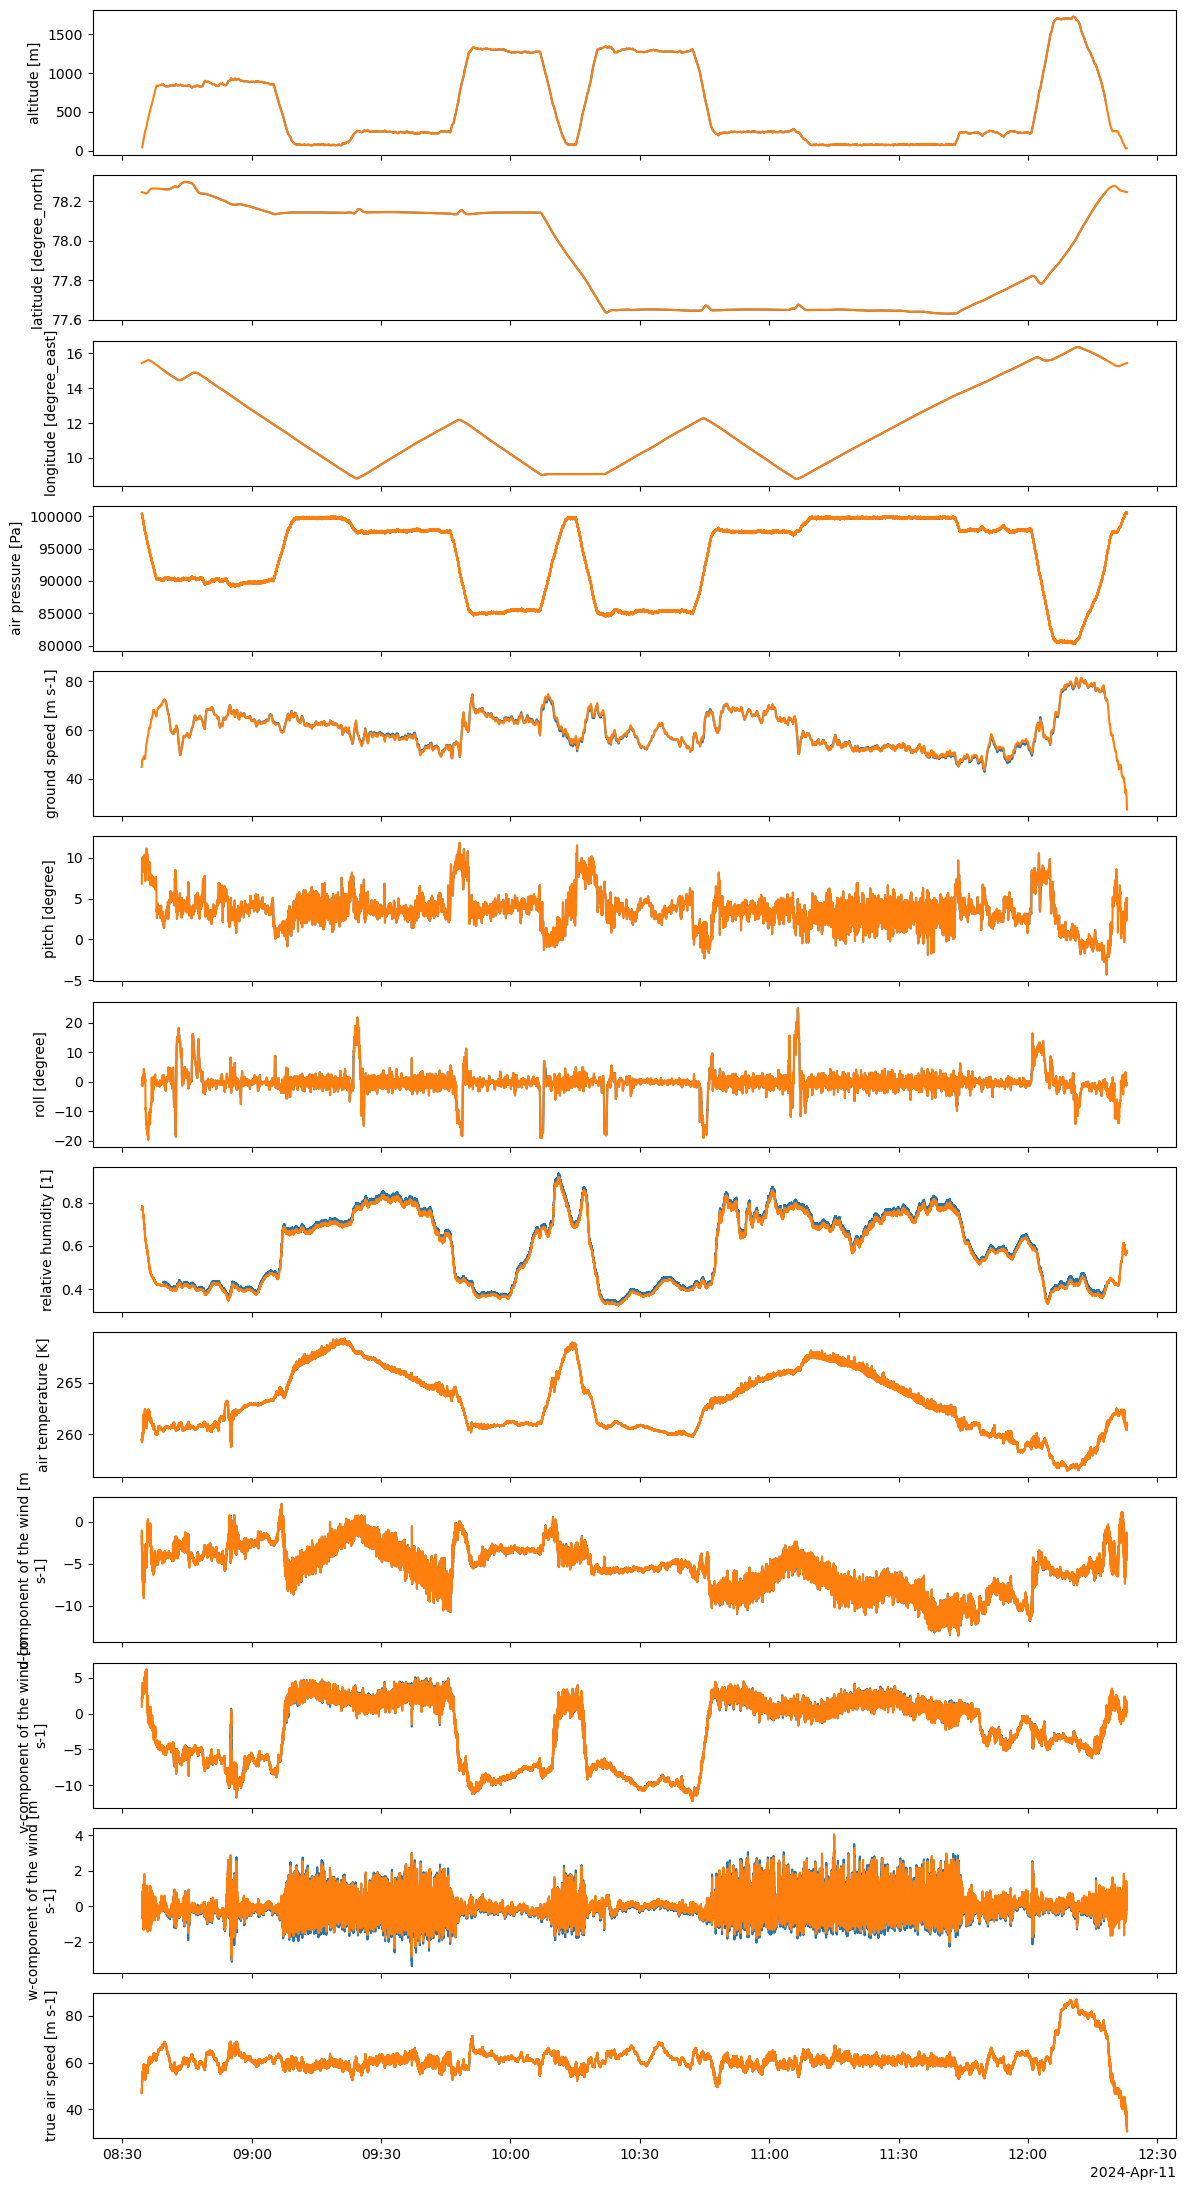

In [6]:
flight = 3
config_fn = "../bacsam2_processing/config_bacsam2.yaml"
config = import_dictionary(config_fn)

try:
    cal_segs = config["flights"][flight]["calibration"]
except:
    print("no calibration segments during this flight")
    cal_segs = {}

date_dict = {1: "20240407", 2: "20240410", 3: "20240411", 40: "20240413", 41: "20240413", 42: "20240413", 5: "20240415", 6: "20240417", 7: "20240423", 8: "20240424", 9: "20240425", 10: "20240426", 11: "20240429"}

date = date_dict[flight]

fn = f"{campaign_dir}/Prozessierung/noseboom/BACSAM2_{date}_RF{flight:02}_noseboom_100Hz.nc"
#fn = f"/Users/lakoeh001/AWI/Campaigns/20260103SANAT/Daten/Prozessierung/SANAT_{date}_RF{flight:02}_noseboom_100Hz.nc"
proc = xr.open_dataset(fn)

fig, axs = plt.subplots(13,1,figsize=(12,22),sharex=True)

if compare2joerg:
    varnames_joerg = { 'alt': 'h', 'lat': 'lat', 'lon':'lon', 'p_air':'p', 'gs':'gs', 'pitch':'pitch', 'roll':'roll', 'rh':'rh', 't_air': 'T', 'u':'u', 'v': 'v', 'w':'w', 'taspd':'tas'}
    for v, ax in zip(list(proc.keys()), fig.get_axes()):
        if v == "rh":
            data2plot = ref[varnames_joerg[v]] /100
        elif v == "t_air":
            data2plot = ref[varnames_joerg[v]] + 273.15
        elif v == "p_air":
            data2plot = ref[varnames_joerg[v]] *100
        else:
            data2plot = ref[varnames_joerg[v]]
        data2plot.sel(time = slice(proc.time.min() + np.timedelta64(5,"m"),proc.time.max() - np.timedelta64(5,"m"))).plot(ax = ax)

for v, ax in zip(list(proc.keys()), fig.get_axes()):
    proc[v].plot(ax = ax)
    ax.set_xlabel("")

for ax in fig.get_axes():
    for key, val in cal_segs.items():
        start = val['start']
        stop = val['stop']
        
        # optional: different colors for "out" vs "ret"
        color = 'red' if 'out' in key else 'blue'
        
        ax.axvspan(start, stop, alpha=0.2, color=color)

plt.tight_layout()

#plt.savefig(f"{campaign_dir}/Prozessierung/plots/BACSAM2_noseboom_RF{flight:02}.png")

In [32]:
flightnumber_dict = {1: 1, 2: 2, 3: 3, 40: 4, 41: 5, 42: 6, 5: 7, 6: 8, 7: 9, 8: 10, 9: 11, 10: 12, 11: 13}
date_dict = {1: "20240407", 2: "20240410", 3: "20240411", 40: "20240413", 41: "20240413", 42: "20240413", 5: "20240415", 6: "20240417", 7: "20240423", 8: "20240424", 9: "20240425", 10: "20240426", 11: "20240429"}

for flight in [1, 2, 3, 40, 41, 42, 5, 6, 7, 8, 9, 10, 11]:
    date = date_dict[flight]
    flight_joerg = flightnumber_dict[flight]

    fn = f"{campaign_dir}/Prozessierung/noseboom/BACSAM2_{date}_RF{flight:02}_noseboom_100Hz.nc"
    proc = xr.open_dataset(fn)

    file = f"{campaign_dir}/Turbulenz/Met_100Hz_Polar6_TB/Flight_{date}_P6_{flight_joerg:02}_100Hz.asc"
    with open(file, "r") as f:
        colnames = f.readline().strip()[1:].split()

    # Only read needed columns
    needed = ["UTC", "u", "v", "w"]
    usecols = [colnames.index(c) for c in needed]
    data_joerg = pd.read_csv(file, sep=r"\s+", comment="!", header=None,
                             usecols=usecols, names=needed, engine="c")

    # Faster time conversion
    base = np.datetime64(f"{date[:4]}-{date[4:6]}-{date[6:]}", "ns")
    times = (np.datetime64(f"{date[:4]}-{date[4:6]}-{date[6:]}") + (data_joerg["UTC"].values * 1e3).astype("int64") * np.timedelta64(1, "ms")).astype("datetime64[ns]")

    # Build xarray directly without going through pandas index
    ref = None
    ref = xr.Dataset(
        {v: ("time", data_joerg[v].values) for v in ["u", "v", "w"]},
        coords={"time": times}
    )
#    ref = ref.sel(time=slice(proc.time.min(), proc.time.max()))
    ref["w"] = ref.w - ref.w.mean()
    ref = ref.interp(time=proc.time)

    print(f"RF{flight:02}:")
    for v in ["u", "v", "w"]:
        diff = (proc[v] - ref[v]).sel(time = slice(proc.time.min() + np.timedelta64(5,"m"), proc.time.max() - np.timedelta64(5,"m"))).values
        mask = np.isfinite(diff)
        diff = diff[mask]
        bias = diff.mean()
        mae  = np.abs(diff).mean()
        rmse = np.sqrt((diff**2).mean())
        print(f"    {v}: bias = {bias:.4f} m/s, mae = {mae:.4f} m/s, rmse = {rmse:.4f} m/s")

RF01:
    u: bias = 0.0015 m/s, mae = 0.0361 m/s, rmse = 0.0492 m/s
    v: bias = -0.0003 m/s, mae = 0.0455 m/s, rmse = 0.0592 m/s
    w: bias = -0.0166 m/s, mae = 0.0273 m/s, rmse = 0.0390 m/s
RF02:
    u: bias = -0.0006 m/s, mae = 0.0608 m/s, rmse = 0.0779 m/s
    v: bias = 0.0000 m/s, mae = 0.0248 m/s, rmse = 0.0350 m/s
    w: bias = -0.0327 m/s, mae = 0.0427 m/s, rmse = 0.0553 m/s
RF03:
    u: bias = 0.0004 m/s, mae = 0.0324 m/s, rmse = 0.0488 m/s
    v: bias = -0.0050 m/s, mae = 0.0788 m/s, rmse = 0.1092 m/s
    w: bias = -0.0367 m/s, mae = 0.0697 m/s, rmse = 0.0978 m/s
RF40:
    u: bias = 0.0469 m/s, mae = 0.0493 m/s, rmse = 0.0564 m/s
    v: bias = 0.0458 m/s, mae = 0.0499 m/s, rmse = 0.0579 m/s
    w: bias = -0.0473 m/s, mae = 0.0491 m/s, rmse = 0.0546 m/s
RF41:
    u: bias = -0.0000 m/s, mae = 0.0461 m/s, rmse = 0.0552 m/s
    v: bias = 0.0000 m/s, mae = 0.0172 m/s, rmse = 0.0228 m/s
    w: bias = -0.0199 m/s, mae = 0.0273 m/s, rmse = 0.0350 m/s
RF42:
    u: bias = -0.0462 m/s

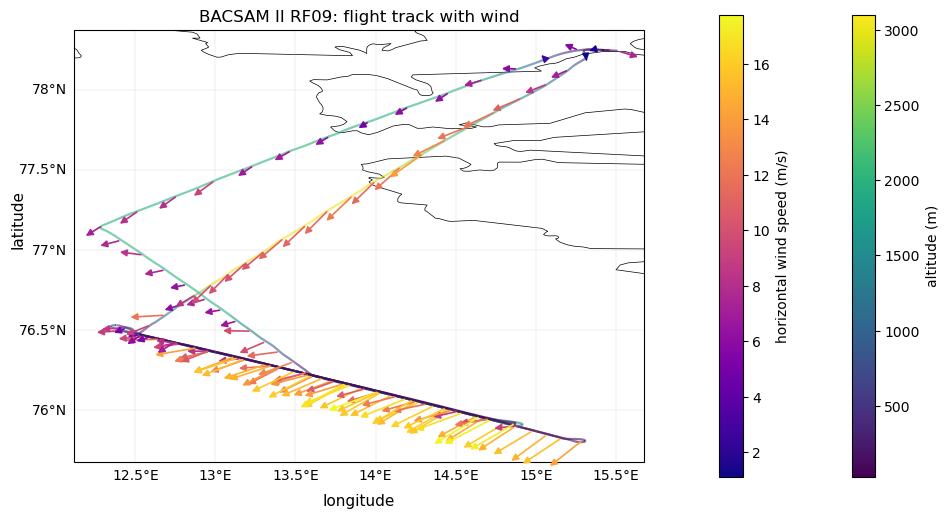

In [388]:
fig, ax = plot_wind_arrows(proc.lat, proc.lon, proc.u, proc.v, proc.alt, flight,
                           track_stride=100,   # every 1 s a track point
                           wind_stride=12000,   # draw every 2 min an arrow
                           wind_avg=1000,       # 10s average
                           scale=0.02)        # Arrow scale (adjust)

#fig.savefig(f"{campaign_dir}/Prozessierung/plots/BACSAM2_windontrack_noseboom_RF{flight:02}.png", bbox_inches='tight')

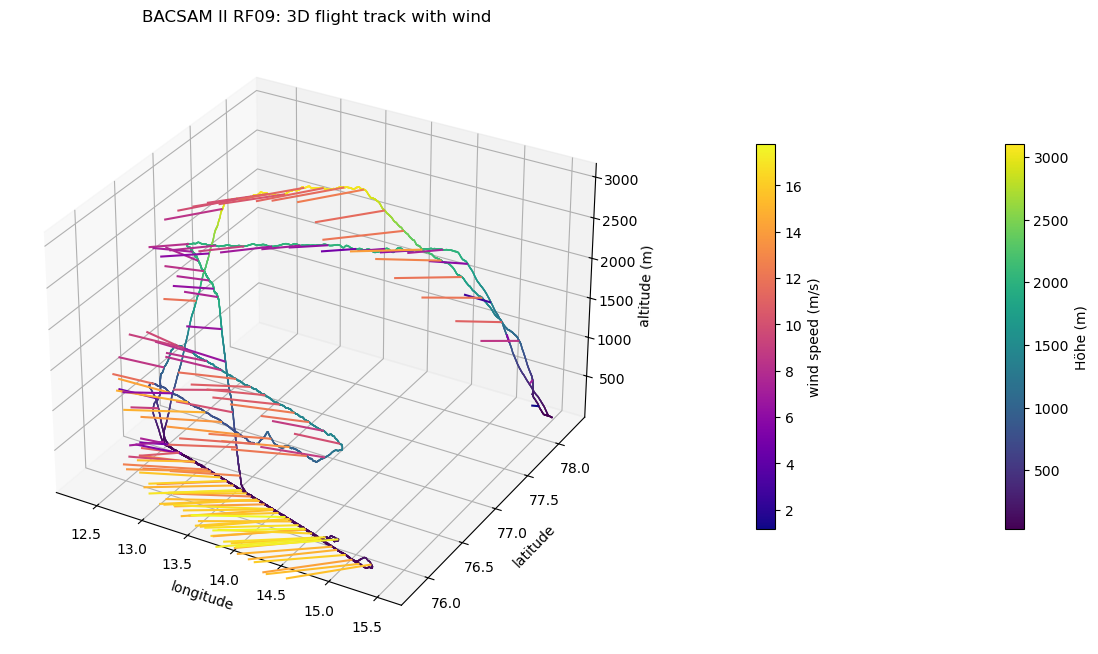

In [389]:
fig, ax = plot_wind_arrows_3d(proc.lat, proc.lon, proc.u, proc.v, proc.w, proc.alt, flight,
                           track_stride=100,   # every 1 s a track point
                           wind_stride=12000,   # draw every 2 min an arrow
                           wind_avg=1000,       # 10s average
                           scale=0.05)        # Arrow scale (adjust)

#fig.savefig(f"{campaign_dir}/Prozessierung/plots/BACSAM2_windontrack_3d_noseboom_RF{flight:02}.png", bbox_inches='tight')